In [13]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import datetime


from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [14]:
import kagglehub
path = kagglehub.dataset_download("sudalairajkumar/daily-temperature-of-major-cities")
print("Path to dataset files:", path)

import os
os.listdir(path)

Path to dataset files: /Users/1an/.cache/kagglehub/datasets/sudalairajkumar/daily-temperature-of-major-cities/versions/1


['city_temperature.csv']

In [31]:
data = pd.read_csv(path + '/city_temperature.csv')
print(data.shape)
data.head()

/var/folders/85/6_l83d_53d13vh2zg9mlxcw40000gn/T/ipykernel_73769/1799479437.py:1: DtypeWarning: Columns (0: State) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path + '/city_temperature.csv')


(2906327, 8)


,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9


In [50]:
sf = data[data['City'] == 'San Francisco']

sf.columns = [col.lower().replace(' ', '_') for col in sf.columns]
sf['date'] = pd.to_datetime(sf[['year', 'month', 'day']])
#sf = sf[sf['year'] >= 2015]
sf = sf[['city', 'date', 'avgtemperature']]
sf = sf[sf['date'] >= '2014-05-13']

sf.columns = ['unique_id', 'ds', 'y']
sf = sf.reset_index(drop=True)

sf.head()


,unique_id,ds,y
0,San Francisco,2014-05-13,70.3
1,San Francisco,2014-05-14,74.8
2,San Francisco,2014-05-15,74.5
3,San Francisco,2014-05-16,63.4
4,San Francisco,2014-05-17,61.1


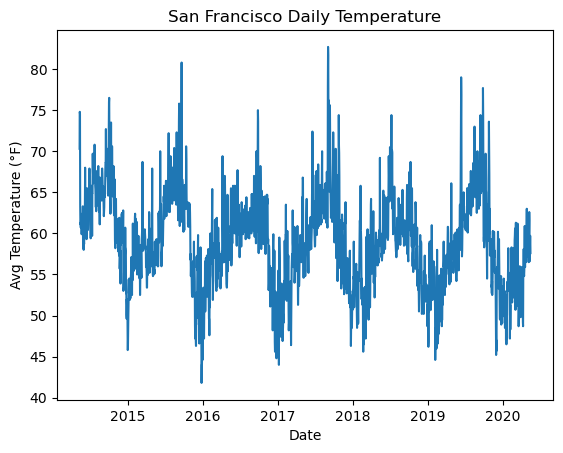

In [52]:
plt.plot(sf.ds, sf.y)
plt.title("San Francisco Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Avg Temperature (°F)")
plt.show()

### Baseline Models

In [61]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

horizon = 365
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size = 365),
    SeasonalNaive(season_length = 365)
]

s_f = StatsForecast(models = models, freq = 'D')
s_f.fit(df = sf)
preds = s_f.predict(h = horizon)
preds = preds.reset_index()

/opt/anaconda3/envs/time_series_analysis/lib/python3.14/site-packages/statsforecast/core.py:492: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


In [62]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,San Francisco,2020-05-14,57.599998,58.90292,58.770958,60.099998
1,San Francisco,2020-05-15,57.599998,58.90292,58.770958,56.500000
2,San Francisco,2020-05-16,57.599998,58.90292,58.770958,56.900002
3,San Francisco,2020-05-17,57.599998,58.90292,58.770958,54.599998
4,San Francisco,2020-05-18,57.599998,58.90292,58.770958,54.200001


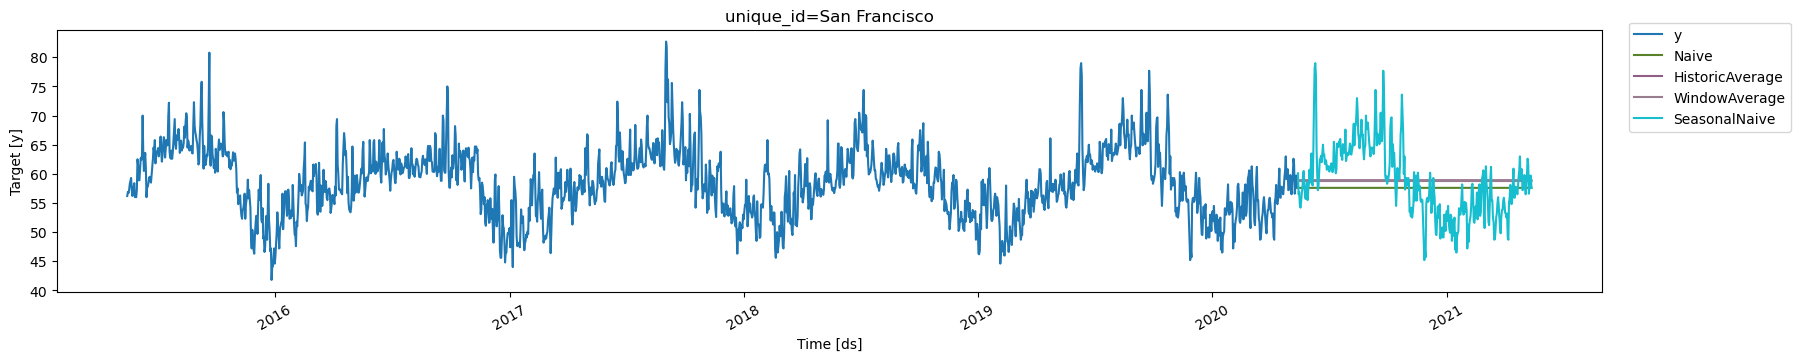

In [64]:
plot_series(
    df = sf,
    forecasts_df = preds,
    ids = ['San Francisco'],
    max_insample_length = 365 * 5
)

In [71]:
test = sf.groupby("unique_id").tail(horizon)
train = sf.drop(test.index).reset_index(drop=True)

s_f.fit(df=train)
preds = s_f.predict(h = horizon)
preds = preds.reset_index() 
eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

evaluation = evaluate(
    eval_df,
    metrics=[mae],
)

evaluation

/opt/anaconda3/envs/time_series_analysis/lib/python3.14/site-packages/statsforecast/core.py:492: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,San Francisco,mae,4.94274,4.973238,4.968225,4.526575


In [72]:
evaluation = evaluation.drop(['unique_id'], axis = 1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,4.94274,4.973238,4.968225,4.526575


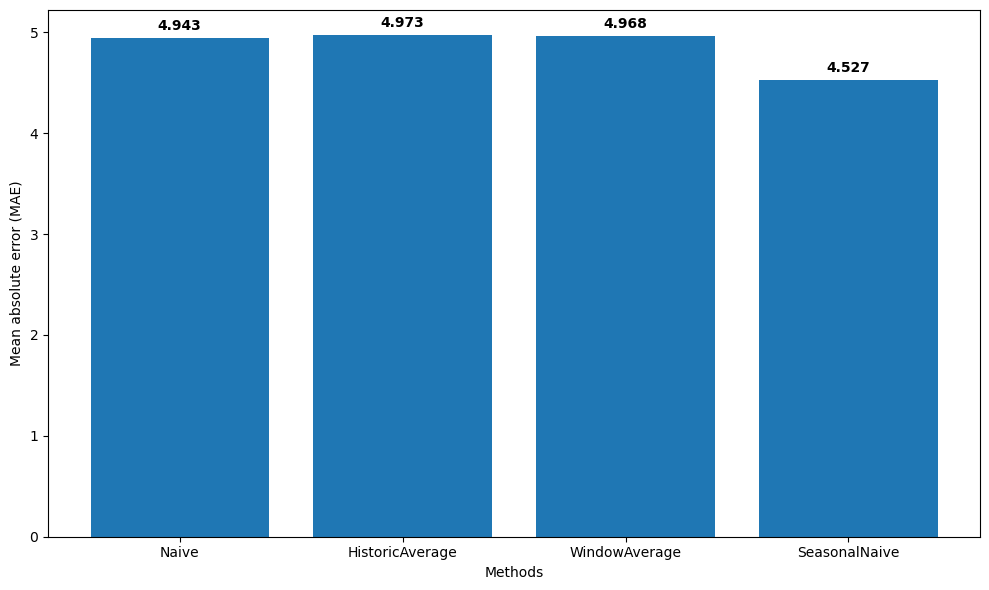

In [74]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha = 'center', va = 'bottom', fontweight = 'bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()